# 01 · The score must mean the right thing

## Goal
Compare a reported price move with an executable trade. Read [Lesson 1](../docs/modules/01-research-loop.md) first.

**Status:** worked example prepared by Codex; learner understanding unassessed. No API calls.

## Setup
Run top to bottom. All examples are synthetic unless explicitly labelled as public evidence.

In [1]:
from pathlib import Path
import sys, json, tempfile
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
assert (ROOT / 'signal_lab').is_dir(), 'Run from the companion root or notebooks directory'
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (8, 4.2), 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})


## Steps

### 1. Calculate independently
Synthetic prices: previous close 100, earliest entry 104, later exit 105. Ten basis points is an assumed **round-trip** cost of entry notional.

In [2]:
from fractions import Fraction
from signal_lab.quant import executable_return
expected = float(Fraction(105,104) - 1 - Fraction(1,1000))
net = executable_return(104,105,10)
assert abs(net - expected) < 1e-12
values = pd.Series({'Unavailable close-to-close': .05, 'Executable gross': 105/104-1, 'Executable net, 10 bps': net})
(values * 100).rename('Return (%)').to_frame()

,Return (%)
Unavailable close-to-close,5.000000
Executable gross,0.961538
"Executable net, 10 bps",0.861538


### 2. See the timing error
Only the latter two bars use an available entry. This is arithmetic, not a measured strategy.

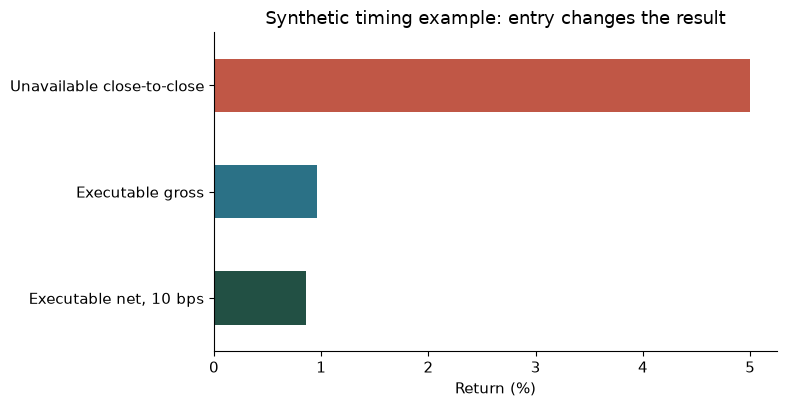

In [3]:
ax=(values*100).plot.barh(color=['#c05746','#2b7186','#225044'])
ax.set(xlabel='Return (%)', title='Synthetic timing example: entry changes the result')
ax.invert_yaxis(); plt.tight_layout(); plt.show()

### 3. Identify the editable surface
Change the cost assumption as a declared sensitivity analysis. Changing entry to an unavailable close violates the experiment. Record those as different interventions.

## Checks
The exact fraction and shared implementation agree. No market data or model calls were used.

## Next Steps
Optional: change the cost to 25 bps. Explain why this differs from changing the entry rule. Then go to [decisions](../docs/modules/02-decisions.md).

**Low energy:** stop here. The checkpoint is optional; reading the worked output does not update mastery.